In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# data
df = pd.read_csv('../data/ACTUAL_qol.csv')

In [2]:
# Select features for clustering (e.g., happiness, health, and education)
# We exclude 'id' and 'year' as they aren't behavior indicators
df['age_health_interaction'] = df['age'] * df['health_new']
df['years_married'] = (df['age'] - df['agewed']).fillna(0) # years since marriage
features = ['happy_new', 'health_new', 'life_new', 'educ', 'age', 'age_health_interaction', 'years_married']
X = df[features].dropna() # K-means cannot handle missing values

# 3. Standardize the data (CRITICAL for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
X.head()

(40353, 7)


,happy_new,health_new,life_new,educ,age,age_health_interaction,years_married
0,0,2,2,6,54,108,25.0
1,2,3,2,8,51,153,30.0
2,1,4,2,11,36,144,19.0
3,1,4,2,12,32,128,5.0
4,1,3,2,8,54,162,36.0


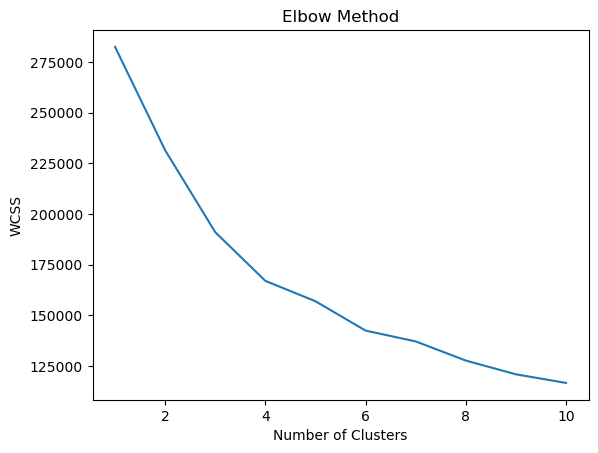

In [3]:
# Find the optimal number of clusters (The Elbow Method)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [4]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 6]:
    model = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    score = silhouette_score(X_scaled, model.labels_)
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=3: 0.1808
Silhouette Score for k=4: 0.1844
Silhouette Score for k=6: 0.1856


In [5]:
# Run the model (4 clusters based on the elbow to balance interpretability and silhouette score)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
X['cluster'] = kmeans.fit_predict(X_scaled)

# View the "Average" person in each cluster
print(X.groupby('cluster').mean())

         happy_new  health_new  life_new       educ        age  \
cluster                                                          
0         1.464308    3.464919  1.239147  13.989682  32.825894   
1         0.723087    2.404996  1.973586  12.438353  40.493257   
2         1.340032    3.404746  1.434264  14.268506  62.331517   
3         1.235076    2.563069  1.745363  10.007757  65.202698   

         age_health_interaction  years_married  
cluster                                         
0                    112.596607       4.369917  
1                     92.697071       4.204772  
2                    209.181767       5.719005  
3                    165.638786      42.142496  


In [8]:
## Inertia (WCSS) for the final model
final_inertia = kmeans.inertia_
print(f"Final Inertia (WCSS) for k=4: {final_inertia:.4f}")

Final Inertia (WCSS) for k=4: 167043.9483


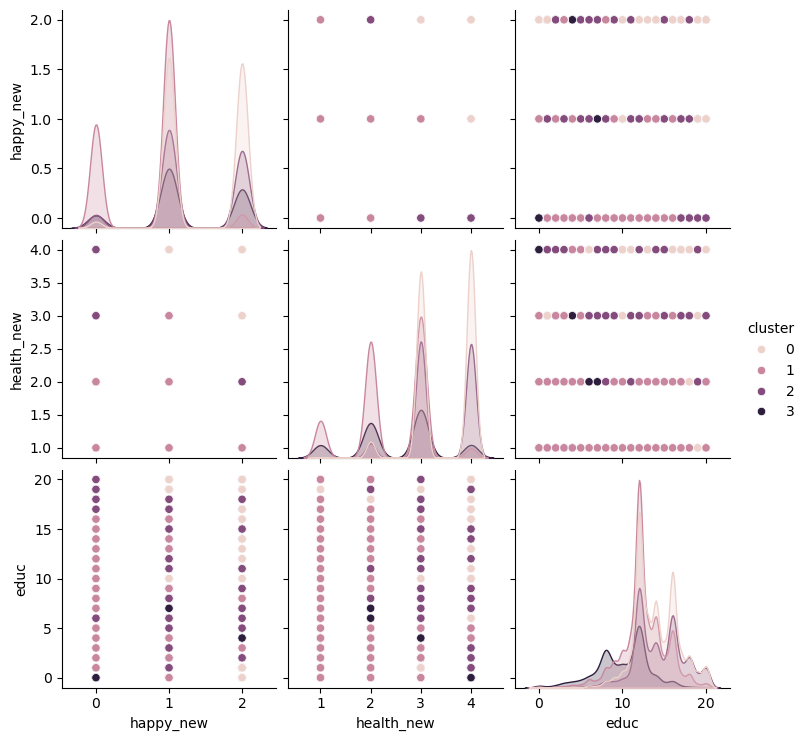

In [6]:
sns.pairplot(X, hue='cluster', vars=['happy_new', 'health_new', 'educ'])
plt.show()

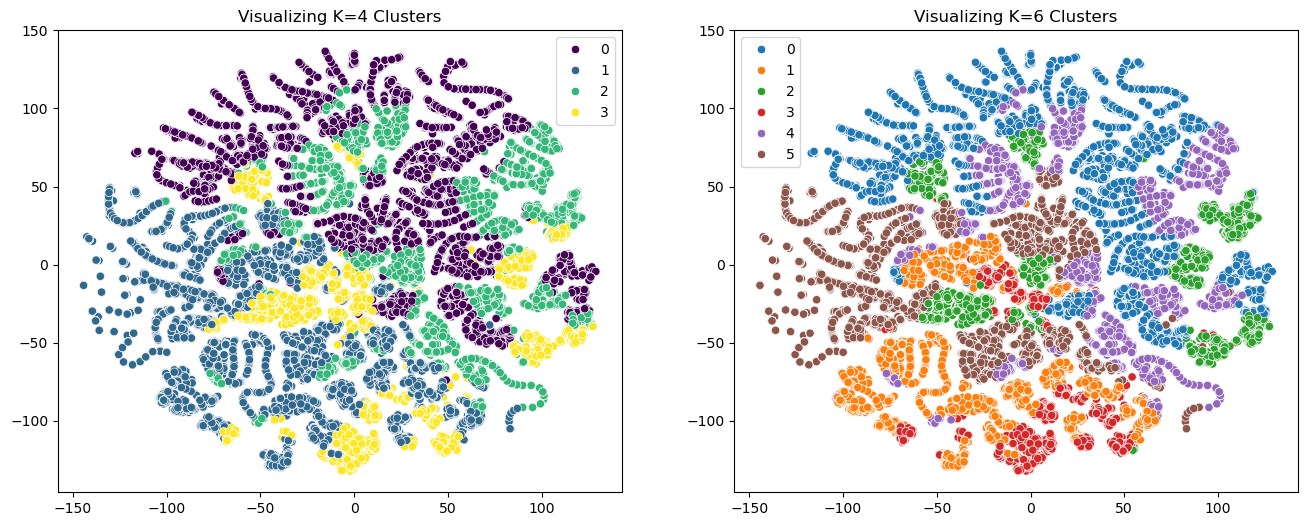

In [7]:
from sklearn.manifold import TSNE

# 1. Standardize and Cluster (using K=3 and K=6 for comparison)
# X_scaled is your scaled feature matrix from the previous step
kmeans4 = KMeans(n_clusters=4, random_state=42).fit(X_scaled)
kmeans6 = KMeans(n_clusters=6, random_state=42).fit(X_scaled)

# 2. Run t-SNE (Squashing dimensions to 2D)
# We sample the data so it runs faster and isn't too crowded
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 3. Plot the results
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=kmeans4.labels_, palette='viridis', ax=ax[0])
ax[0].set_title('Visualizing K=4 Clusters')

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=kmeans6.labels_, palette='tab10', ax=ax[1])
ax[1].set_title('Visualizing K=6 Clusters')
plt.show()

In [9]:
## also report the DBI between clusters n = 4 and n = 6
from sklearn.metrics import davies_bouldin_score
dbi_4 = davies_bouldin_score(X_scaled, kmeans4.labels_)
dbi_6 = davies_bouldin_score(X_scaled, kmeans6.labels_)
print(f"Davies-Bouldin Index for K=4: {dbi_4:.4f}")
print(f"Davies-Bouldin Index for K=6: {dbi_6:.4f}")

Davies-Bouldin Index for K=4: 1.5752
Davies-Bouldin Index for K=6: 1.6080


In [10]:
## report the purity compared to label "happy_new" (using a threshold to create binary labels)
import numpy as np

def purity_score(y_true, y_pred):
    # Create a contingency matrix
    contingency_matrix = pd.crosstab(y_true, y_pred)
    
    # Calculate purity
    purity = np.sum(np.amax(contingency_matrix.values, axis=0)) / np.sum(contingency_matrix.values)
    return purity

In [11]:
## print purity scores for K=4 and K=6
purity_4 = purity_score(X['happy_new'], kmeans4.labels_)
purity_6 = purity_score(X['happy_new'], kmeans6.labels_)
print(f"Purity Score for K=4: {purity_4:.4f}")
print(f"Purity Score for K=6: {purity_6:.4f}")

Purity Score for K=4: 0.5529
Purity Score for K=6: 0.5912
